In [3]:
#installing packages
!pip install librosa joblib
!pip install soundfile
!pip install numpy
!pip install pandas
!pip install scikit-learn
!pip install tensorflow
!pip install matplotlib
!pip install seaborn
!pip install tqdm

In [4]:
#Importing Libraries
import os
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
#Dataset path
dataset_path = "/content/drive/MyDrive/Actors_voice_dataset"

In [7]:
os.listdir(dataset_path)

['Actor_01',
 'Actor_03',
 'Actor_02',
 'Actor_05',
 'Actor_09',
 'Actor_06',
 'Actor_04',
 'Actor_07',
 'Actor_08',
 'Actor_10',
 'Actor_11',
 'Actor_12',
 'Actor_16',
 'Actor_13',
 'Actor_14',
 'Actor_15',
 'Actor_19',
 'Actor_20',
 'Actor_17',
 'Actor_18',
 'Actor_22',
 'Actor_21',
 'Actor_23',
 'Actor_24']

In [8]:
#Load Dataset
paths = []
labels = []

for root, dirs, files in os.walk(dataset_path):

    for file in files:

        if file.endswith(".wav"):

            path = os.path.join(root, file)

            emotion = file.split("-")[2]

            paths.append(path)
            labels.append(emotion)

df = pd.DataFrame()

df["path"] = paths
df["emotion"] = labels

print("Total files:", len(df))
df.head()

Total files: 1440


,path,emotion
0,/content/drive/MyDrive/Actors_voice_dataset/Ac...,02
1,/content/drive/MyDrive/Actors_voice_dataset/Ac...,01
2,/content/drive/MyDrive/Actors_voice_dataset/Ac...,02
3,/content/drive/MyDrive/Actors_voice_dataset/Ac...,02
4,/content/drive/MyDrive/Actors_voice_dataset/Ac...,02


In [9]:
#Emotion Label Encoding
encoder = LabelEncoder()
df["emotion"] = encoder.fit_transform(df["emotion"])

In [10]:
#Data Augmentation
def add_noise(data):

    noise_amp = 0.035*np.random.uniform()*np.amax(data)

    data = data + noise_amp*np.random.normal(size=data.shape[0])

    return data


def pitch_shift(data, sr):

    return librosa.effects.pitch_shift(data, sr=sr, n_steps=2)

In [11]:
#Feature Extraction (Mel Spectrogram)
def extract_features(file):

    audio, sr = librosa.load(file, duration=2.5, offset=0.6)

    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
    mfcc = np.mean(mfcc.T, axis=0)

    chroma = librosa.feature.chroma_stft(y=audio, sr=sr)
    chroma = np.mean(chroma.T, axis=0)

    mel = librosa.feature.melspectrogram(y=audio, sr=sr)
    mel = np.mean(mel.T, axis=0)

    contrast = librosa.feature.spectral_contrast(y=audio, sr=sr)
    contrast = np.mean(contrast.T, axis=0)

    zcr = librosa.feature.zero_crossing_rate(audio)
    zcr = np.mean(zcr)

    features = np.hstack([mfcc, chroma, mel, contrast, zcr])

    return features

In [12]:
#Create Feature Dataset
X = []
y = []

for path, emotion in tqdm(zip(df.path, df.emotion), total=len(df)):

    feature = extract_features(path)

    X.append(feature)
    y.append(emotion)

    # augmentation
    audio, sr = librosa.load(path, duration=2.5, offset=0.6)

    noise_audio = add_noise(audio)
    feature_noise = extract_features(path)

    X.append(feature_noise)
    y.append(emotion)

X = np.array(X)
y = np.array(y)

print(X.shape)

100%|██████████| 1440/1440 [21:48<00:00,  1.10it/s]

(2880, 188)


In [13]:
print(X.shape)

(2880, 188)


In [14]:
#Feature Normalization
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [15]:
#Save Scaler
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [16]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
#CNN Model
model = Sequential()

model.add(Dense(512, activation='relu', input_shape=(X_train.shape[1],)))
model.add(BatchNormalization())
model.add(Dropout(0.4))

model.add(Dense(256, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.4))

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))

model.add(Dense(8, activation='softmax'))

model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │        96,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 272,840 (1.04 MB)

 Trainable params: 271,304 (1.03 MB)

 Non-trainable params: 1,536 (6.00 KB)

In [18]:
#Early Stopping
early_stop = EarlyStopping(
monitor='val_loss',
patience=10,
restore_best_weights=True
)

In [20]:
#Train Model
history = model.fit(
X_train,
y_train,
epochs=80,
batch_size=32,
validation_data=(X_test,y_test),
callbacks=[early_stop]
)

Epoch 1/80
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9175 - loss: 0.2466 - val_accuracy: 0.9115 - val_loss: 0.3762
Epoch 2/80
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9084 - loss: 0.2784 - val_accuracy: 0.9062 - val_loss: 0.3843
Epoch 3/80
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9054 - loss: 0.2798 - val_accuracy: 0.9045 - val_loss: 0.3212
Epoch 4/80
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9184 - loss: 0.2527 - val_accuracy: 0.9323 - val_loss: 0.2679
Epoch 5/80
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9184 - loss: 0.2398 - val_accuracy: 0.9271 - val_loss: 0.2620
Epoch 6/80
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9171 - loss: 0.2507 - val_accuracy: 0.9115 - val_loss: 0.3371
Epoch 7/80
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9201 - loss: 0.2291 - val_accuracy: 0.9132 - val_loss: 0.2726
Epoch 8/80
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9258 - loss: 0.2255 - val_accuracy: 0.9219 - val_loss:

In [21]:
import tensorflow as tf
model.export("emotion_saved_model")

Saved artifact at 'emotion_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 188), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 8), dtype=tf.float32, name=None)
Captures:
  132511426730256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132511426731984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132511426730448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132511426729296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132511426724688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132511426733712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132511426732176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132511426729488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132511433603984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132511433603792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132511426733136: Te

In [22]:
from google.colab import files
!zip -r emotion_saved_model.zip emotion_saved_model
files.download("emotion_saved_model.zip")

  adding: emotion_saved_model/ (stored 0%)
  adding: emotion_saved_model/variables/ (stored 0%)
  adding: emotion_saved_model/variables/variables.data-00000-of-00001 (deflated 8%)
  adding: emotion_saved_model/variables/variables.index (deflated 68%)
  adding: emotion_saved_model/saved_model.pb (deflated 87%)
  adding: emotion_saved_model/fingerprint.pb (stored 0%)
  adding: emotion_saved_model/assets/ (stored 0%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

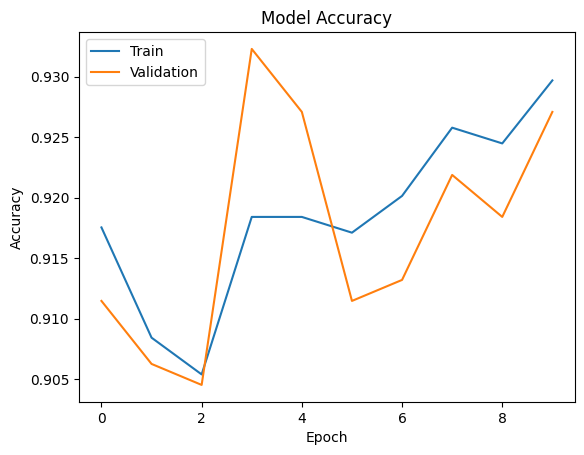

In [23]:
#Training Visualization
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

In [24]:
#Evaluate Model
loss, accuracy = model.evaluate(X_test,y_test)
print("Test Accuracy:", accuracy)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9115 - loss: 0.3762 
Test Accuracy: 0.9114583134651184


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step  


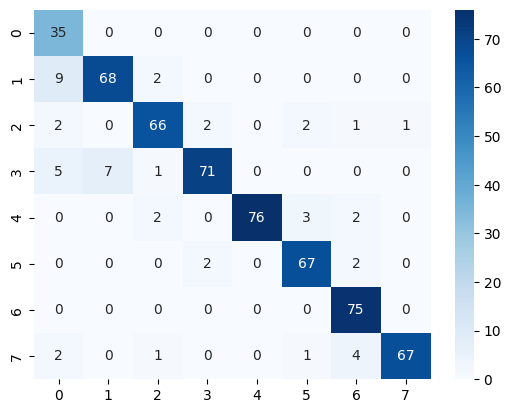

In [25]:
#Confusion Matrix
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred,axis=1)

cm = confusion_matrix(y_test,y_pred)

sns.heatmap(cm,annot=True,cmap="Blues")

plt.show()